In [1]:
%matplotlib inline
import re
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# ファイルパスと変換係数
scan_dir = Path("/home/yamamoto/Work/chemistry/orca-work/MEA_CO2_water_afify/scan")
log_path = scan_dir / "scan.log"
HARTREE_TO_KJMOL = 2625.499638

# ログを読み込み
text = log_path.read_text(errors="ignore")
print(f"ログファイル: {log_path}")

ログファイル: /home/yamamoto/Work/chemistry/orca-work/MEA_CO2_water_afify/scan/scan.log


In [3]:
# 各スキャンステップの最終エネルギーを抽出
# スキャンステップの位置を取得
scan_steps = [
    (m.start(), int(m.group(1)))
    for m in re.finditer(r"RELAXED SURFACE SCAN STEP\s+(\d+)", text)
]

# 各ステップの最終エネルギー（最後の FINAL SINGLE POINT ENERGY）を抽出
final_energies_per_step = []
step_numbers = []

for i, (pos, step_num) in enumerate(scan_steps):
    if i + 1 < len(scan_steps):
        search_range = text[pos : scan_steps[i + 1][0]]
    else:
        search_range = text[pos:]

    energy_matches = re.findall(
        r"FINAL SINGLE POINT ENERGY\s+(-\d+\.\d+)", search_range
    )
    if energy_matches:
        final_energy = float(energy_matches[-1])  # 最後のエネルギー値
        final_energies_per_step.append(final_energy)
        step_numbers.append(step_num)

print(f"抽出: {len(final_energies_per_step)} スキャンステップ")

抽出: 20 スキャンステップ


In [4]:
# 単位変換と相対エネルギー計算
final_E_kjmol = np.array(final_energies_per_step) * HARTREE_TO_KJMOL
final_dE_kjmol = final_E_kjmol - np.min(final_E_kjmol)

# スキャン座標（C-CO2距離）を計算
# ログから: Bond(12,1) range=3.00000000 .. 1.50000000 steps=20
initial_distance = 3.00  # Ångström
final_distance = 1.50  # Ångström
n_steps = len(step_numbers)
# 線形補間
distances = initial_distance - (np.array(step_numbers) - 1) * (
    initial_distance - final_distance
) / (n_steps - 1)

# データフレーム作成
df_final = pd.DataFrame(
    {
        "step": step_numbers,
        "distance_angstrom": distances,
        "energy_hartree": final_energies_per_step,
        "energy_kJmol": final_E_kjmol,
        "delta_kJmol": final_dE_kjmol,
    }
)

print(df_final[["step", "distance_angstrom", "delta_kJmol"]])

    step  distance_angstrom  delta_kJmol
0      1           3.000000     0.000000
1      2           2.921053     0.194165
2      3           2.842105     0.541910
3      4           2.763158     0.689724
4      5           2.684211     1.489882
5      6           2.605263     2.443603
6      7           2.526316     3.818329
7      8           2.447368     5.492416
8      9           2.368421     7.367258
9     10           2.289474     9.319103
10    11           2.210526    11.080072
11    12           2.131579    12.338819
12    13           2.052632    12.783890
13    14           1.973684    12.228574
14    15           1.894737    10.635227
15    16           1.815789     8.175438
16    17           1.736842     5.416045
17    18           1.657895     3.437966
18    19           1.578947     4.217695
19    20           1.500000    11.096900


/tmp/ipykernel_808263/1922338170.py:15: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
/tmp/ipykernel_808263/1922338170.py:16: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.savefig(scan_dir / "scan_energy_profile.png", dpi=200, bbox_inches="tight")
/home/yamamoto/Work/chemistry/orca-work/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


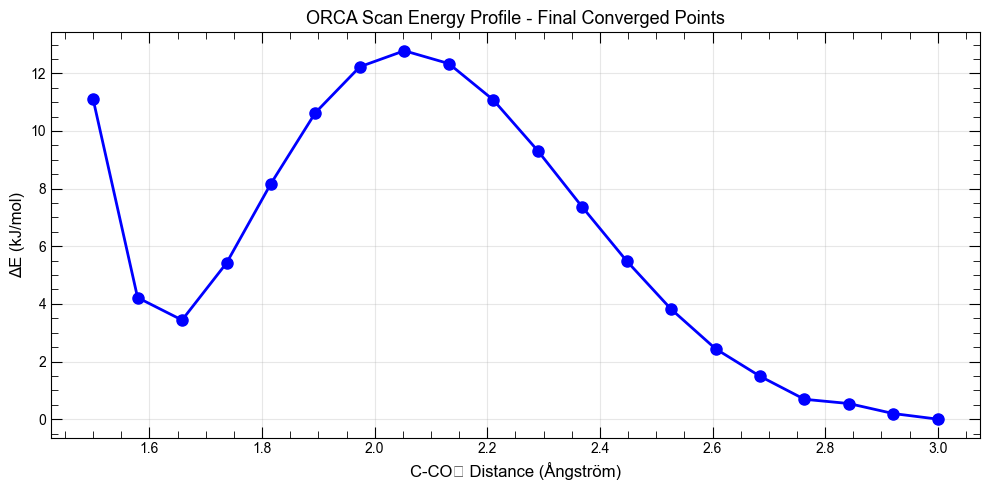

プロット保存: /home/yamamoto/Work/chemistry/orca-work/MEA_CO2_water_afify/scan/scan_energy_profile.png


In [5]:
# プロット
plt.figure(figsize=(10, 5))
plt.plot(
    df_final["distance_angstrom"],
    df_final["delta_kJmol"],
    marker="o",
    markersize=8,
    linewidth=2,
    color="blue",
)
plt.xlabel("C-CO₂ Distance (Ångström)", fontsize=12)
plt.ylabel("ΔE (kJ/mol)", fontsize=12)
plt.title("ORCA Scan Energy Profile - Final Converged Points", fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(scan_dir / "scan_energy_profile.png", dpi=200, bbox_inches="tight")
plt.show()

print(f'プロット保存: {scan_dir / "scan_energy_profile.png"}')

In [6]:
# CSV保存
csv_path = scan_dir / "scan_energy_profile.csv"
df_final.to_csv(csv_path, index=False)
print(f"CSV保存: {csv_path}")
print(f"\n統計:")
print(df_final[["distance_angstrom", "delta_kJmol"]].describe())

CSV保存: /home/yamamoto/Work/chemistry/orca-work/MEA_CO2_water_afify/scan/scan_energy_profile.csv

統計:
       distance_angstrom  delta_kJmol
count          20.000000    20.000000
mean            2.250000     6.138351
std             0.467059     4.538078
min             1.500000     0.000000
25%             1.875000     2.205173
50%             2.250000     5.454230
75%             2.625000    10.746439
max             3.000000    12.783890
